In [1]:
import pandas as pd
import cygno as cygno
import glob
import uproot 
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import awkward as ak
from tqdm.notebook import tqdm
import os
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

In [2]:
from configs import *
from functions import *

In [3]:
f"setting the folder to save the outputs"
main_folder_to_save = '../HG_LG_normalization'
if not os.path.exists(main_folder_to_save):
    os.makedirs(main_folder_to_save)

In [4]:
f"reading logbook"
logbook_df = cygno.read_cygno_logbook()
logbook_df = logbook_df.rename(columns={'run_number' : 'run'})

In [5]:
f"correcting positions"
logbook_df['corrected_source_position'] = (logbook_df['source_position']).map(wrong_to_wright_position_dict)

In [6]:
f"adding step information"
logbook_df['step'] = (logbook_df['corrected_source_position']).map(correct_position_to_step_dict)

In [7]:
f"setting the mask for high and low gain runs selection"
mask_gen = (logbook_df['source_type'] == 1) & (logbook_df.run >= lime_underground_run_numbers_dict['Run 4'][0]) & (logbook_df.run <= lime_underground_run_numbers_dict['Run 4'][1]) & (logbook_df.run_description.isin(steps_of_interest) ) 

mask_hg = mask_gen & (logbook_df.GEM1_V == 440)     
mask_lg = mask_gen & (logbook_df.GEM1_V == 400)         

In [63]:
logbook_df[mask_hg].columns

Index(['run', 'run_description', 'start_time', 'exposure_sec', 'GEM3_V',
       'GEM2_V', 'GEM1_V', 'T2_V', 'T1_V', 'DRIFT_V', 'OFFSET_V', 'PMT1_V',
       'PMT2_V', 'PMT3_V', 'PMT4_V', 'HV_STATE', 'total_gas_flow',
       'sequencer_running', 'sequence_filename', 'pmt_acquisition',
       'pedestal_run', 'source_type', 'source_position',
       'discrimination_threshold', 'trigger_veto_time', 'trigger_logic',
       'run_type', 'drs4_correction_active', 'shielding_configuration',
       'stop_time', 'number_of_events', 'storage_local_status',
       'storage_cloud_status', 'storage_tape_status', 'file_size',
       'file_checksum', 'file_s3_tag', 'online_reco_status', 'run_quality',
       'corrected_source_position', 'step'],
      dtype='object')

In [65]:
# =========================
# USAGE (in your notebook)
# =========================
from configs import lime_underground_run_numbers_dict, steps_of_interest, data_directory
#
# logbook_df must already exist
#
# 1) Add GEM_V + gas_gain columns
logbook_hg = add_gain_columns_to_logbook(logbook_df[mask_hg])
logbook_lg = add_gain_columns_to_logbook(logbook_df[mask_lg])

In [97]:
run_list_lg = logbook_lg.run.values
run_list_hg = logbook_hg.run.values

In [80]:
# 2) Build datasets for Run 4
#run_range = tuple(lime_underground_run_numbers_dict["Run 4"])  # adjust key if needed
#datasets, selected_runs_df = build_datasets_from_logbook_vgem(
#     logbook2, run_range=run_range, steps_of_interest=steps_of_interest, only_hg_lg=True
# )
f"setting the path to the cloud folder with the data"
run_to_analyse = f"Run4"
data_directory = f"/jupyter-workspace/cnaf-storage/cygno-analysis/RECO/{run_to_analyse}"
datasets_hg = load_rectangular_data_fast(run_list_hg, data_directory)

[WARN] run 43518 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43518_3D.root
in object /Events;1
[WARN] run 43519 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43519_3D.root
in object /Events;1
[WARN] run 43520 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43520_3D.root
in object /Events;1
[WARN] run 43521 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43521_3D.root
in object /Events;1
[WARN] run 43522 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43522_3D.root
in object /Events;1
[WARN] run 43525 not loaded: not found: 'Mixture_Density'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43525_3D.root
in object /Events;1
[WARN] run

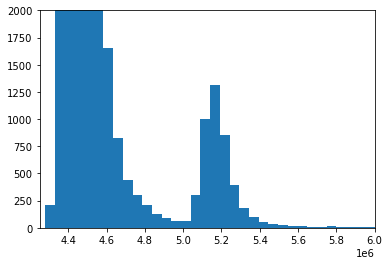

In [94]:
plt.hist(datasets_hg.cmos_integral, bins = 60)
plt.xlim(4.25e6,6e6)
plt.ylim(0,2000)
plt.show()

In [98]:
datasets_lg = load_rectangular_data_fast(run_list_lg, data_directory)

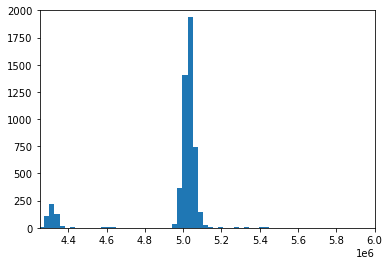

In [100]:
plt.hist(datasets_lg.cmos_integral, bins = 60)
plt.xlim(4.25e6,6e6)
plt.ylim(0,2000)
plt.show()

In [122]:
datasets_hg.t_saturation

0        1.475215e-06
1        1.452863e-06
2        1.162291e-06
3        2.119690e-06
4        2.836809e-06
             ...     
39625    8.316711e-07
39626    1.312234e-06
39627    1.894310e-06
39628    1.371838e-06
39629    5.895272e-07
Name: t_saturation, Length: 39630, dtype: float32

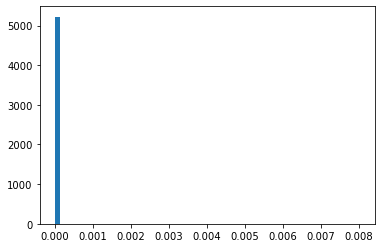

In [118]:
plt.hist(datasets_lg.t_saturation, bins = 60)
#plt.xlim(4.25e6,6e6)
#plt.ylim(0,2000)
plt.show()

In [117]:
for sat in datasets_lg.columns

Index(['run', 'event', 'pedestal_run', 'cmos_integral', 'cmos_mean',
       'cmos_rms', 't_saturation', 't_zerosup', 'nSc', 'nRedpix',
       'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature',
       'Humidity', 'Mixture_Density', 'Run'],
      dtype='object')

In [101]:
f"loading jagged data"
jagged_data_hg_df = load_jagged_data(run_list_hg, data_directory)
jagged_data_lg_df = load_jagged_data(run_list_lg, data_directory)

In [116]:
jagged_data_lg_df.columns

Index(['sc_size', 'sc_nhits', 'sc_integral', 'sc_corrintegral', 'sc_rms',
       'sc_energy', 'sc_pathlength', 'sc_theta', 'sc_length', 'sc_width',
       'sc_longrms', 'sc_latrms', 'sc_lfullrms', 'sc_tfullrms',
       'sc_lp0amplitude', 'sc_lp0prominence', 'sc_lp0fwhm', 'sc_lp0mean',
       'sc_tp0fwhm', 'sc_xmean', 'sc_ymean', 'sc_xmax', 'sc_xmin', 'sc_ymax',
       'sc_ymin', 'sc_pearson', 'sc_tgaussamp', 'sc_tgaussmean',
       'sc_tgausssigma', 'sc_tchi2', 'sc_tstatus', 'sc_lgaussamp',
       'sc_lgaussmean', 'sc_lgausssigma', 'sc_lchi2', 'sc_lstatus', 'Run'],
      dtype='object')

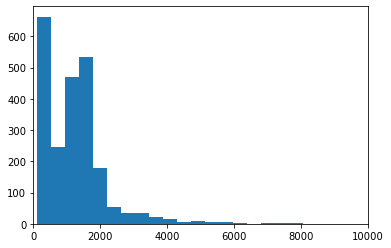

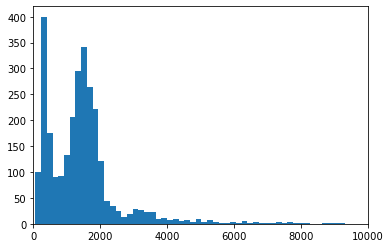

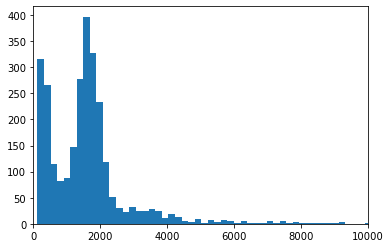

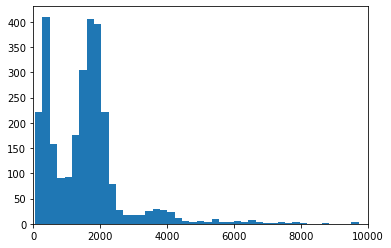

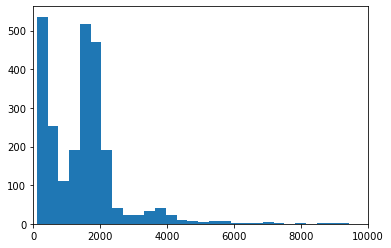

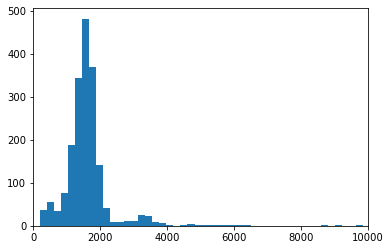

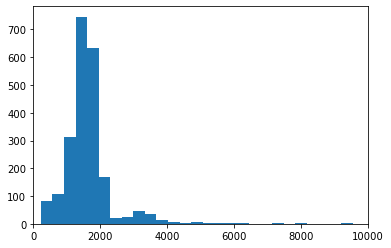

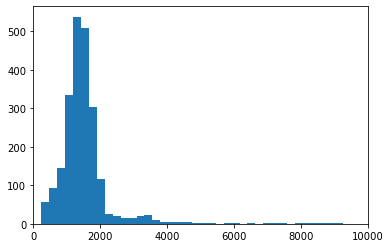

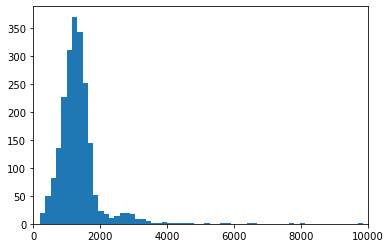

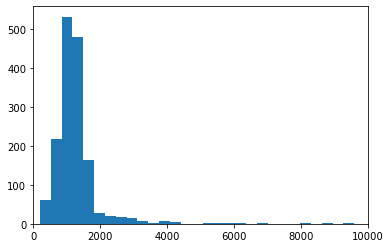

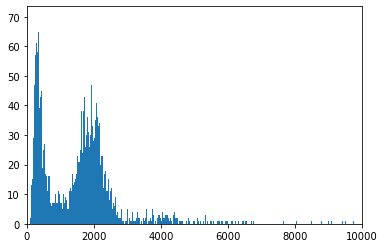

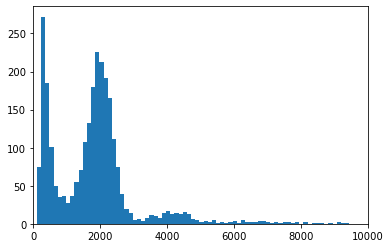

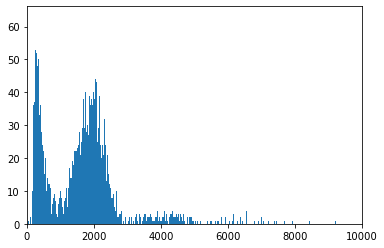

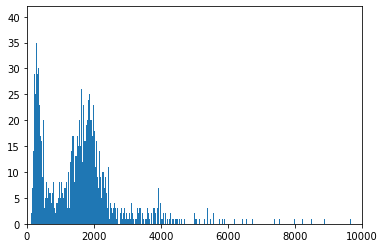

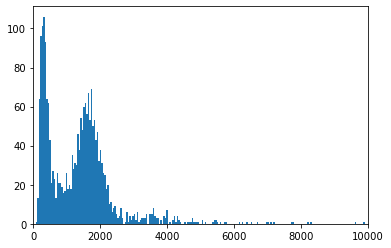

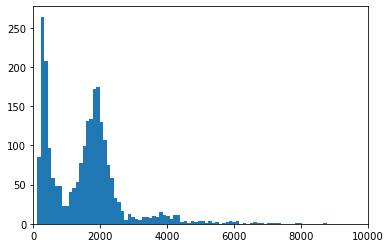

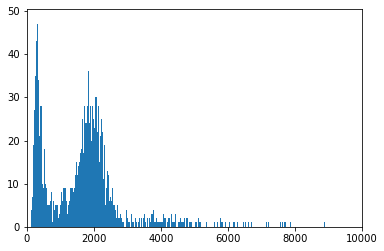

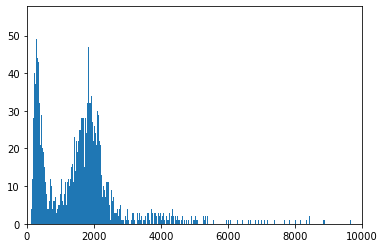

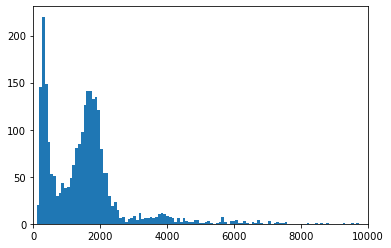

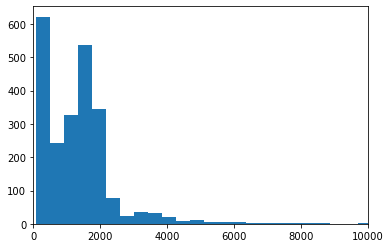

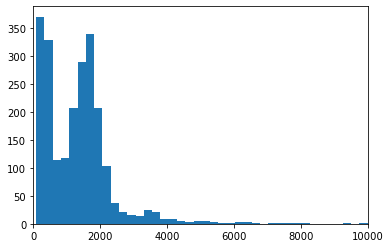

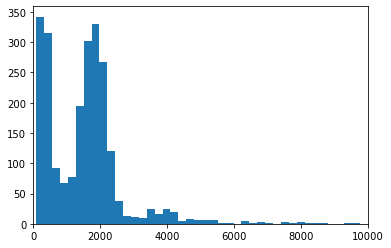

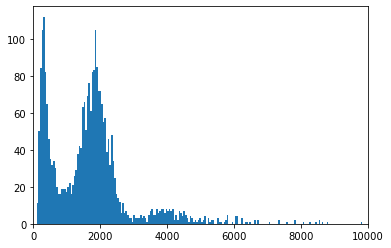

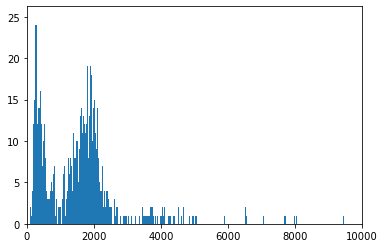

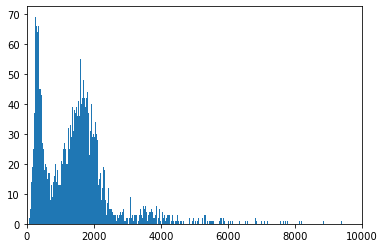

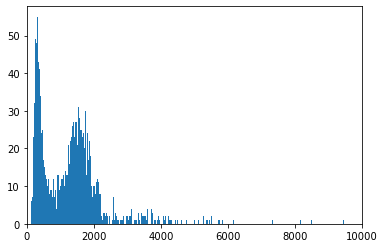

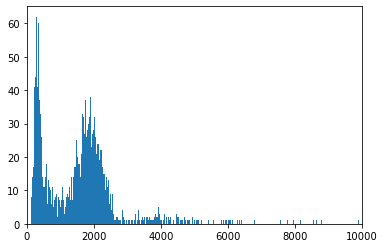

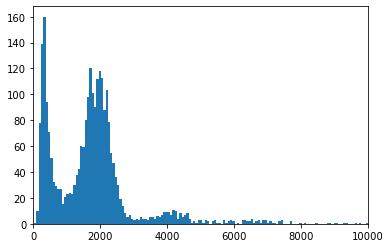

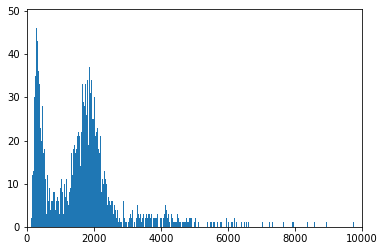

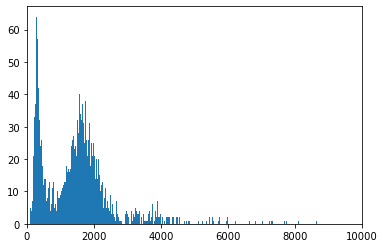

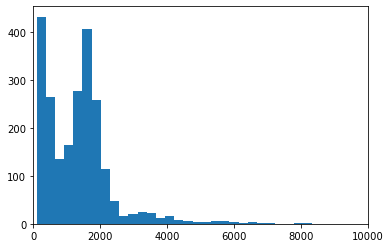

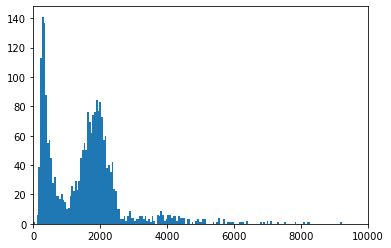

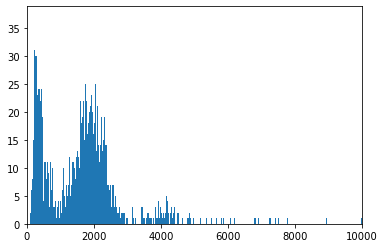

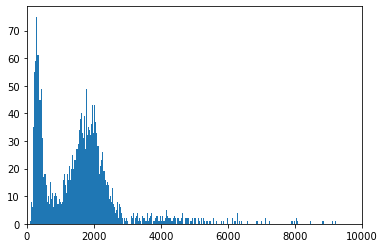

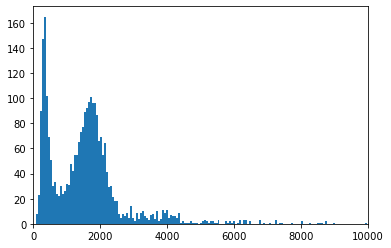

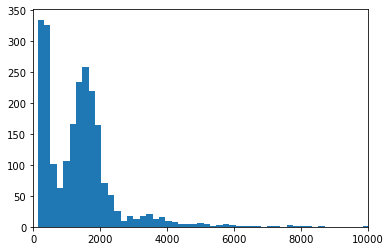

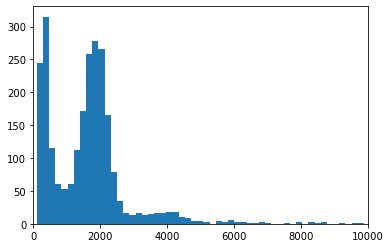

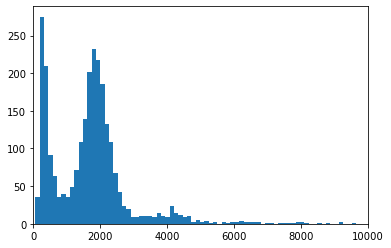

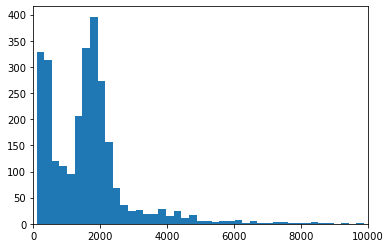

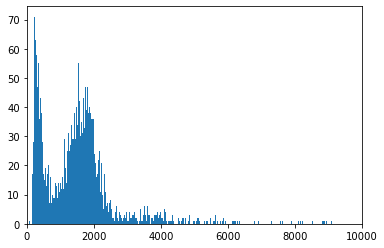

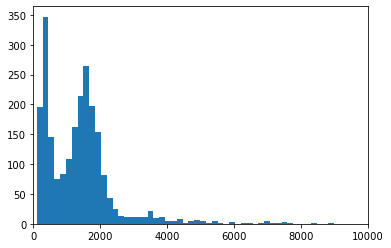

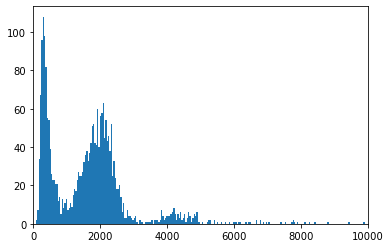

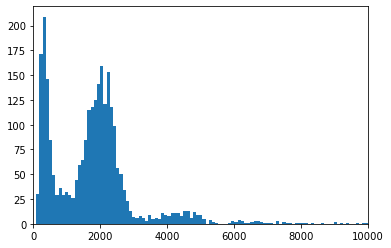

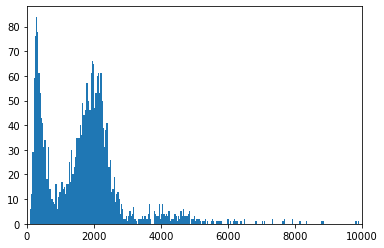

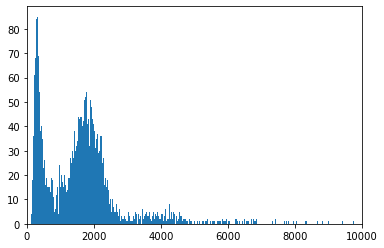

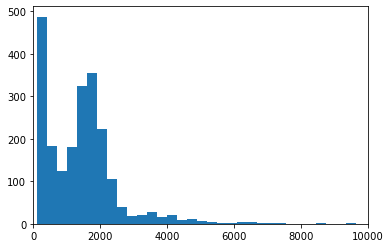

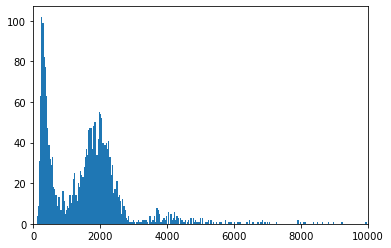

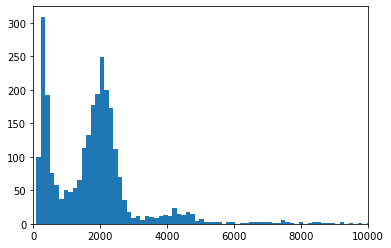

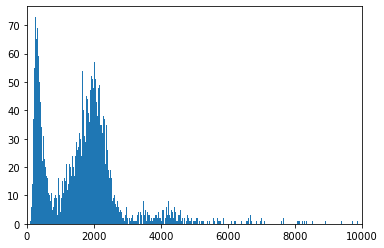

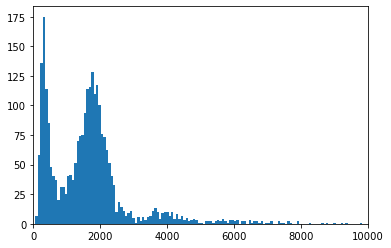

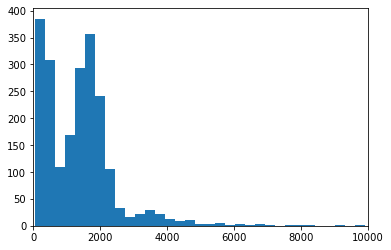

In [115]:
for run in jagged_data_lg_df.Run.unique():
    plt.hist(jagged_data_lg_df[jagged_data_lg_df.Run == run].sc_integral, label = f'{run}', bins = 2040)
    plt.xlim(0,10000)
    plt.show()

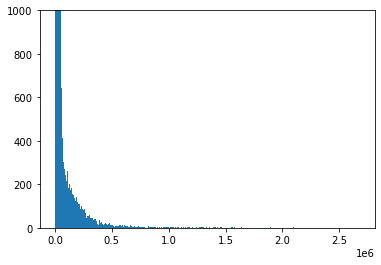

In [107]:
plt.hist(jagged_data_hg_df.sc_integral, bins = 400)
plt.ylim(0,1000)
plt.show()

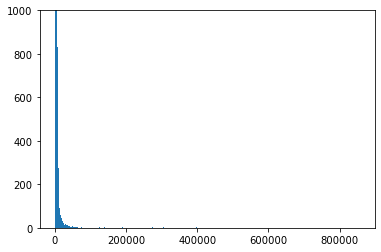

In [108]:
plt.hist(jagged_data_lg_df.sc_integral, bins = 400)
plt.ylim(0,1000)
plt.show()

In [79]:
# =========================
# FULL PIPELINE (fresh copy)
# =========================
# Goal:
# 1) Build datasets from logbook_df using "gas_gain" defined by GEM voltages:
#       HG if GEM1=GEM2=GEM3=440
#       LG if GEM1=GEM2=GEM3=400
# 2) Load ROOT reconstructed data into df_all with metadata propagated
# 3) Issue #2: saturation metrics per dataset/condition
# 4) Issue #1: HG vs LG energy-spectrum cross-check (Fe), normalized to Fe peak area
#
# Assumptions:
# - logbook_df exists (from notebook cells 7/8)
# - configs provide: data_directory, steps_of_interest, lime_underground_run_numbers_dict for Run 4
# - ROOT files are in data_directory with naming reco_run0{run}_3D.root / reco_run{run}_3D.root
# - Reco tree name is "Events" with branches listed in RECT_COLS

import os
import re
import numpy as np
import pandas as pd
import uproot
import awkward as ak
import matplotlib.pyplot as plt

# -------------------------
# 0) Fast loader (rectangular)
# -------------------------
RECT_COLS = [
    'run','event','pedestal_run',
    'cmos_integral','cmos_mean','cmos_rms',
    't_saturation','t_zerosup',
    'nSc','nRedpix',
    'Lime_pressure','Atm_pressure',
    'Lime_temperature','Atm_temperature',
    'Humidity','Mixture_Density'
]

def load_rectangular_data_fast(run_list, directory, extra_meta=None, verbose=True):
    """
    Load reconstructed rectangular branches for a list of runs into a single DataFrame.
    Adds meta columns from extra_meta to every row.
    """
    rows = []
    for run in run_list:
        try:
            file_path = (
                f"{directory}/reco_run0{run}_3D.root" if run < 10000
                else f"{directory}/reco_run{run}_3D.root"
            )
            tree = uproot.open(file_path)["Events"]
            arr = tree.arrays(RECT_COLS, library="ak")
            df = pd.DataFrame({c: ak.to_numpy(arr[c]) for c in RECT_COLS})

            df["Run"] = run  # keep a consistent capitalized column as well

            if extra_meta:
                for k, v in extra_meta.items():
                    df[k] = v

            rows.append(df)

        except Exception as e:
            if verbose:
                print(f"[WARN] run {run} not loaded: {e}")

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


# -------------------------
# 1) Define gas_gain from GEM voltages (your new definition)
# -------------------------
def classify_gas_gain(gem_v):
    if gem_v == 440:
        return "HG"
    if gem_v == 400:
        return "LG"
    return "OTHER"


def add_gain_columns_to_logbook(logbook_df):
    """
    Adds:
      - GEM_V (collapsed because GEM1=GEM2=GEM3 expected)
      - gas_gain (HG/LG/OTHER based on GEM_V)
    Also checks that GEM1=GEM2=GEM3; prints a sample if not.
    """
    df = logbook_df.copy()

    same_gem_mask = (
        (df["GEM1_V"] == df["GEM2_V"]) &
        (df["GEM2_V"] == df["GEM3_V"])
    )

    if not same_gem_mask.all():
        print("[WARN] Found runs where GEM1_V, GEM2_V, GEM3_V are not identical.")
        display(df.loc[~same_gem_mask, ["run","run_description","GEM1_V","GEM2_V","GEM3_V"]].head(20))

        # fallback: use mean GEM voltage (rounded) to define GEM_V
        df["GEM_V"] = np.round((df["GEM1_V"] + df["GEM2_V"] + df["GEM3_V"]) / 3).astype(int)
    else:
        df["GEM_V"] = df["GEM1_V"].astype(int)

    df["gas_gain"] = df["GEM_V"].apply(classify_gas_gain)
    return df


# -------------------------
# 2) Parse run_description to get kind + step
# -------------------------
def parse_description_kind_step(desc: str):
    d = (desc or "").strip()

    if re.search(r"\bBKG\b|Background", d, re.IGNORECASE):
        kind = "BKG"
    elif re.search(r"\b55Fe\b|\bFe\b|Fe Calibration|Daily Calibration", d, re.IGNORECASE):
        kind = "Fe"
    else:
        kind = "Other"

    m = re.search(r"step\s*([1-5])", d, re.IGNORECASE)
    step = int(m.group(1)) if m else None
    return kind, step


# -------------------------
# 3) Build dataset mapping from logbook_df (Run4 + steps_of_interest)
#    Group by: kind, gas_gain, step, GEM_V, DRIFT_V
# -------------------------
def build_datasets_from_logbook_vgem(
    logbook_df_with_gain,
    run_range,
    steps_of_interest,
    only_hg_lg=True
):
    start, stop = run_range

    mask = (
        (logbook_df_with_gain["source_type"] == 1) &
        (logbook_df_with_gain["run"] >= start) &
        (logbook_df_with_gain["run"] <= stop) &
        (logbook_df_with_gain["run_description"].isin(steps_of_interest))
    )

    df = logbook_df_with_gain.loc[mask].copy()

    # kind + step from description
    parsed = df["run_description"].apply(parse_description_kind_step)
    df["kind"] = parsed.apply(lambda x: x[0])
    df["step"] = parsed.apply(lambda x: x[1])

    if only_hg_lg:
        df = df[df["gas_gain"].isin(["HG", "LG"])]

    group_cols = ["kind", "gas_gain", "step", "GEM_V", "DRIFT_V"]

    datasets = {}
    for key, g in df.groupby(group_cols):
        meta = dict(zip(group_cols, key))

        dataset_id = (
            f"{meta['kind']}_step{meta['step']}_{meta['gas_gain']}"
            f"_GEM{meta['GEM_V']}_DV{meta['DRIFT_V']}"
        )

        datasets[dataset_id] = {
            "runs": sorted(g["run"].unique().tolist()),
            "meta": meta
        }

    return datasets, df


# -------------------------
# 4) Load all datasets into df_all (metadata propagated!)
# -------------------------
def load_all_datasets(datasets, data_directory, verbose=True):
    dfs = []
    for dataset_id, pack in datasets.items():
        df = load_rectangular_data_fast(
            pack["runs"],
            directory=data_directory,
            extra_meta={"dataset_id": dataset_id, **pack["meta"]},
            verbose=verbose
        )
        if not df.empty:
            dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


# -------------------------
# 5) Issue #2 - Saturation metrics
# -------------------------
def saturation_metrics(df):
    if df.empty:
        return {}

    sat = df["t_saturation"].fillna(0).to_numpy() > 0
    out = {
        "n_events": int(len(df)),
        "n_saturated": int(sat.sum()),
        "frac_saturated": float(sat.mean()),
        "cmos_integral_p50": float(np.nanpercentile(df["cmos_integral"], 50)),
        "cmos_integral_p95": float(np.nanpercentile(df["cmos_integral"], 95)),
        "cmos_integral_p99": float(np.nanpercentile(df["cmos_integral"], 99)),
    }
    if sat.any():
        s = df.loc[sat, "cmos_integral"].to_numpy()
        out.update({
            "sat_cmos_integral_p50": float(np.nanpercentile(s, 50)),
            "sat_cmos_integral_p95": float(np.nanpercentile(s, 95)),
            "sat_cmos_integral_p99": float(np.nanpercentile(s, 99)),
        })
    if "nRedpix" in df.columns:
        out["nRedpix_p95"] = float(np.nanpercentile(df["nRedpix"], 95))

    return out


def saturation_report(df_all, by_cols):
    rows = []
    for key, g in df_all.groupby(by_cols):
        if not isinstance(key, tuple):
            key = (key,)
        row = dict(zip(by_cols, key))
        row.update(saturation_metrics(g))
        rows.append(row)

    return pd.DataFrame(rows).sort_values("frac_saturated", ascending=False)


# -------------------------
# 6) Issue #1 - HG vs LG spectrum overlay (Fe), normalized to Fe peak area
# -------------------------
def hist(x, bins):
    h, e = np.histogram(x, bins=bins)
    c = 0.5*(e[:-1] + e[1:])
    return c, h

def find_peak_center(x, bins, search_quantile=0.98):
    x = x[np.isfinite(x)]
    if len(x) < 200:
        return np.nan

    xmax = np.quantile(x, search_quantile)
    c, h = hist(x, bins)
    m = (c <= xmax)
    if not np.any(m):
        return np.nan

    return float(c[m][np.argmax(h[m])])

def normalize_to_peak_area(x, bins, peak_center, half_window):
    c, h = hist(x, bins)
    m = (c >= peak_center-half_window) & (c <= peak_center+half_window)
    area = float(h[m].sum())
    scale = 1.0/area if area > 0 else np.nan
    return c, h*scale, scale

def overlay_hg_lg_for_condition(df_all, step, gem_v, drift_v, bins=250, half_window=80):
    """
    Overlays Fe spectra HG vs LG for a given (step, GEM_V, DRIFT_V).
    Uses df_all['gas_gain'] definition (HG=440, LG=400).
    """
    base = (
        (df_all["kind"] == "Fe") &
        (df_all["step"] == step) &
        (df_all["GEM_V"] == gem_v) &
        (df_all["DRIFT_V"] == drift_v)
    )

    df_hg = df_all[base & (df_all["gas_gain"] == "HG")]
    df_lg = df_all[base & (df_all["gas_gain"] == "LG")]

    if df_hg.empty or df_lg.empty:
        print(f"[INFO] Missing HG/LG pair for step={step}, GEM_V={gem_v}, DRIFT_V={drift_v}")
        return

    # remove saturated events for shape comparison / peak finding
    x_hg = df_hg[df_hg["t_saturation"].fillna(0) == 0]["cmos_integral"].to_numpy()
    x_lg = df_lg[df_lg["t_saturation"].fillna(0) == 0]["cmos_integral"].to_numpy()

    p_hg = find_peak_center(x_hg, bins)
    p_lg = find_peak_center(x_lg, bins)

    c_hg, h_hg, _ = normalize_to_peak_area(x_hg, bins, p_hg, half_window)
    c_lg, h_lg, _ = normalize_to_peak_area(x_lg, bins, p_lg, half_window)

    plt.figure(figsize=(10,4))
    plt.step(c_hg, h_hg, where="mid", label=f"HG (GEM=440) peak@{p_hg:.1f}")
    plt.step(c_lg, h_lg, where="mid", label=f"LG (GEM=400) peak@{p_lg:.1f}")
    plt.yscale("log")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.xlabel("cmos_integral (a.u.)")
    plt.ylabel("Counts (normalized to Fe peak area)")
    plt.title(f"Fe step {step} | GEM_V={gem_v} | DRIFT_V={drift_v}")
    plt.legend()
    plt.tight_layout()
    plt.show()


def list_conditions_with_both_gains(df_all, step):
    """
    Returns list of DRIFT_V values that have BOTH GEM_V=440 and GEM_V=400
    for Fe runs at a given step.
    """
    fe = df_all[(df_all["kind"] == "Fe") & (df_all["step"] == step)]
    conds = []

    for dv, g in fe.groupby("DRIFT_V"):
        gem_vals = set(g["GEM_V"].unique())
        if 440 in gem_vals and 400 in gem_vals:
            conds.append(dv)

    return sorted(conds)


def overlay_by_drift_compare_gem(df_all, step, drift_v, bins=250, half_window=80):
    """
    Since your HG/LG is defined by GEM_V, the natural comparison is:
      HG -> GEM_V=440 vs LG -> GEM_V=400
    at the SAME drift_v and step.
    """
    df_hg = df_all[(df_all["kind"]=="Fe") & (df_all["step"]==step) & (df_all["DRIFT_V"]==drift_v) & (df_all["GEM_V"]==440)]
    df_lg = df_all[(df_all["kind"]=="Fe") & (df_all["step"]==step) & (df_all["DRIFT_V"]==drift_v) & (df_all["GEM_V"]==400)]

    if df_hg.empty or df_lg.empty:
        print(f"[INFO] Missing GEM=440 or GEM=400 for step={step}, DRIFT_V={drift_v}")
        return

    x_hg = df_hg[df_hg["t_saturation"].fillna(0) == 0]["cmos_integral"].to_numpy()
    x_lg = df_lg[df_lg["t_saturation"].fillna(0) == 0]["cmos_integral"].to_numpy()

    p_hg = find_peak_center(x_hg, bins)
    p_lg = find_peak_center(x_lg, bins)

    c_hg, h_hg, _ = normalize_to_peak_area(x_hg, bins, p_hg, half_window)
    c_lg, h_lg, _ = normalize_to_peak_area(x_lg, bins, p_lg, half_window)

    plt.figure(figsize=(10,4))
    plt.step(c_hg, h_hg, where="mid", label=f"GEM 440 (HG) peak@{p_hg:.1f}")
    plt.step(c_lg, h_lg, where="mid", label=f"GEM 400 (LG) peak@{p_lg:.1f}")
    plt.yscale("log")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.xlabel("cmos_integral (a.u.)")
    plt.ylabel("Counts (normalized to Fe peak area)")
    plt.title(f"Fe step {step} | DRIFT_V={drift_v} | Compare GEM 440 vs 400")
    plt.legend()
    plt.tight_layout()
    plt.show()




In [21]:
df_all

,run,event,pedestal_run,cmos_integral,cmos_mean,cmos_rms,t_saturation,t_zerosup,nSc,nRedpix,...,Atm_temperature,Humidity,Mixture_Density,Run,dataset_id,kind,gas_gain,step,GEM_V,DRIFT_V
0,41162,0,41160,4439360.0,0.836287,2.275185,0.000001,0.153573,18,15488,...,21.270071,-4.657814,1.390504,41162,Fe_step1_HG_GEM440_DV960,Fe,HG,1,440,960
1,41162,1,41160,4373673.5,0.823913,2.193924,0.000001,0.575398,15,12608,...,21.270071,-4.657814,1.390504,41162,Fe_step1_HG_GEM440_DV960,Fe,HG,1,440,960
2,41162,2,41160,4377814.0,0.824693,2.212484,0.000001,0.406657,19,13888,...,21.270071,-4.657814,1.390504,41162,Fe_step1_HG_GEM440_DV960,Fe,HG,1,440,960
3,41162,3,41160,4480825.5,0.844098,2.299841,0.000002,0.293285,18,36384,...,21.270071,-4.657814,1.390504,41162,Fe_step1_HG_GEM440_DV960,Fe,HG,1,440,960
4,41162,4,41160,4354760.5,0.820350,2.185955,0.000003,0.285671,15,12832,...,21.270071,-4.657814,1.390504,41162,Fe_step1_HG_GEM440_DV960,Fe,HG,1,440,960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44848,51890,98,51884,5013678.0,0.944477,2.052213,0.000001,0.049106,27,10672,...,21.589542,-3.967913,1.391959,51890,Fe_step5_LG_GEM400_DV960,Fe,LG,5,400,960
44849,51890,99,51884,5038733.5,0.949197,2.054895,0.000002,0.055273,15,5792,...,21.589542,-3.967913,1.391959,51890,Fe_step5_LG_GEM400_DV960,Fe,LG,5,400,960
44850,51890,100,51884,5036875.0,0.948847,2.313506,0.000001,0.049141,10,2336,...,21.589542,-3.967913,1.391959,51890,Fe_step5_LG_GEM400_DV960,Fe,LG,5,400,960
44851,51890,101,51884,5034442.0,0.948389,2.059795,0.000002,0.054955,19,13456,...,21.589542,-3.967913,1.391959,51890,Fe_step5_LG_GEM400_DV960,Fe,LG,5,400,960


In [22]:
# 4) Issue #2: saturation report
rep = saturation_report(df_all, ["kind","gas_gain","step","GEM_V","DRIFT_V"])
display(rep.head(50))


,kind,gas_gain,step,GEM_V,DRIFT_V,n_events,n_saturated,frac_saturated,cmos_integral_p50,cmos_integral_p95,cmos_integral_p99,sat_cmos_integral_p50,sat_cmos_integral_p95,sat_cmos_integral_p99,nRedpix_p95
0,Fe,HG,1,440,960,7997,7997,1.0,4412312.50,5125562.30,5259664.460,4412312.50,5125562.30,5259664.460,55264.0
1,Fe,HG,2,440,960,7983,7983,1.0,4475789.50,5179469.90,5311745.890,4475789.50,5179469.90,5311745.890,65707.2
2,Fe,HG,3,440,960,7990,7990,1.0,4510908.25,5213826.35,5335994.715,4510908.25,5213826.35,5335994.715,67857.6
3,Fe,HG,4,440,960,7868,7868,1.0,4516248.00,5213673.85,5348238.230,4516248.00,5213673.85,5348238.230,70178.4
4,Fe,HG,5,440,960,7792,7792,1.0,4462082.50,5173408.15,5347474.265,4462082.50,5173408.15,5347474.265,63388.8
5,Fe,LG,1,400,960,1025,1025,1.0,5024963.50,5072553.60,5157510.780,5024963.50,5072553.60,5157510.780,22889.6
6,Fe,LG,2,400,960,1021,1021,1.0,5029253.50,5076595.00,5141967.300,5029253.50,5076595.00,5141967.300,25472.0
7,Fe,LG,3,400,960,1019,1019,1.0,5030593.50,5073962.50,5108075.900,5030593.50,5073962.50,5108075.900,27531.2
8,Fe,LG,4,400,960,1025,1025,1.0,5027565.00,5074896.50,5107800.960,5027565.00,5074896.50,5107800.960,28217.6
9,Fe,LG,5,400,960,1133,1133,1.0,5020001.50,5070367.40,5256902.580,5020001.50,5070367.40,5256902.580,26336.0


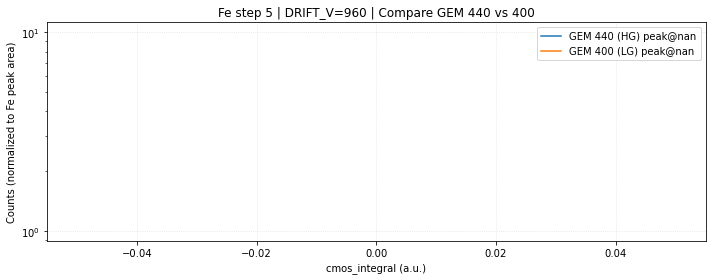

In [26]:
# 5) Issue #1: compare GEM 440 vs 400 at the same drift and step (recommended for your definition)
drifts = list_conditions_with_both_gains(df_all, step=5)
for dv in drifts:
    overlay_by_drift_compare_gem(df_all, step=5, drift_v=dv)

In [28]:
sorted(df_all["step"].dropna().unique())

[1, 2, 3, 4, 5]

In [29]:
sorted(df_all["GEM_V"].dropna().unique())

[400, 440]

In [30]:
df_all[(df_all["kind"]=="Fe") & (df_all["step"]==5)].shape

(8925, 23)

In [31]:
df_all["step"] = pd.to_numeric(df_all["step"], errors="coerce")
df_all["GEM_V"] = pd.to_numeric(df_all["GEM_V"], errors="coerce")
df_all["DRIFT_V"] = pd.to_numeric(df_all["DRIFT_V"], errors="coerce")
df_all["t_saturation"] = pd.to_numeric(df_all["t_saturation"], errors="coerce")
df_all["cmos_integral"] = pd.to_numeric(df_all["cmos_integral"], errors="coerce")

In [38]:
df_all.columns

Index(['run', 'event', 'pedestal_run', 'cmos_integral', 'cmos_mean',
       'cmos_rms', 't_saturation', 't_zerosup', 'nSc', 'nRedpix',
       'Lime_pressure', 'Atm_pressure', 'Lime_temperature', 'Atm_temperature',
       'Humidity', 'Mixture_Density', 'Run', 'dataset_id', 'kind', 'gas_gain',
       'step', 'GEM_V', 'DRIFT_V'],
      dtype='object')

In [44]:
def overlay_by_drift_compare_gem_debug(df_all, step, variable, drift_v, bins=250, half_window=80, drop_saturated=True):
    sel_base = (
        (df_all["kind"]=="Fe") &
        (df_all["step"]==step) &
        (df_all["DRIFT_V"]==drift_v)
    )

    df_hg = df_all[sel_base & (df_all["GEM_V"]==440)]
    df_lg = df_all[sel_base & (df_all["GEM_V"]==400)]

    print(f"[DEBUG] step={step}, DRIFT_V={drift_v}")
    print(f"[DEBUG] HG rows (GEM=440): {len(df_hg)} | LG rows (GEM=400): {len(df_lg)}")

    if df_hg.empty or df_lg.empty:
        print("[DEBUG] One side is empty -> check filters/types/kind labels.")
        return

    if drop_saturated:
        df_hg2 = df_hg[df_hg["t_saturation"].fillna(0)==0]
        df_lg2 = df_lg[df_lg["t_saturation"].fillna(0)==0]
    else:
        df_hg2, df_lg2 = df_hg, df_lg

    print(f"[DEBUG] After saturation filter: HG={len(df_hg2)} | LG={len(df_lg2)}")

    x_hg = df_hg2[variable].dropna().to_numpy()
    x_lg = df_lg2[variable].dropna().to_numpy()

    print(f"[DEBUG] cmos_integral valid: HG={len(x_hg)} | LG={len(x_lg)}")
    if len(x_hg) < 50 or len(x_lg) < 50:
        print("[DEBUG] Too few events to plot/normalize. Try drop_saturated=False or check data.")
        return

    # peak finding
    p_hg = find_peak_center(x_hg, bins)
    p_lg = find_peak_center(x_lg, bins)
    print(f"[DEBUG] Peak centers: HG={p_hg} | LG={p_lg}")

    if not np.isfinite(p_hg) or not np.isfinite(p_lg):
        print("[DEBUG] Peak center is NaN -> histogram range/quantile too restrictive or data empty.")
        return

    c_hg, h_hg, s_hg = normalize_to_peak_area(x_hg, bins, p_hg, half_window)
    c_lg, h_lg, s_lg = normalize_to_peak_area(x_lg, bins, p_lg, half_window)
    print(f"[DEBUG] Peak-area scales: HG={s_hg} | LG={s_lg}")

    if not np.isfinite(s_hg) or not np.isfinite(s_lg):
        print("[DEBUG] Normalization failed (peak window area=0). Increase half_window or bins.")
        return

    plt.figure(figsize=(10,4))
    plt.step(c_hg, h_hg, where="mid", label=f"GEM 440 (HG) peak@{p_hg:.1f}")
    plt.step(c_lg, h_lg, where="mid", label=f"GEM 400 (LG) peak@{p_lg:.1f}")
    plt.yscale("log")
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.xlabel(f"{variable} (a.u.)")
    plt.ylabel("Counts (normalized to Fe peak area)")
    plt.title(f"Fe step {step} | DRIFT_V={drift_v} | Compare GEM 440 vs 400")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [48]:
drifts = list_conditions_with_both_gains(df_all, step=1)
print("DRIFT_V with both GEMs:", drifts)

for dv in drifts[:3]:  # test first 3
    overlay_by_drift_compare_gem_debug(df_all, 1, "sc_integral", drift_v=dv, drop_saturated=False)

DRIFT_V with both GEMs: [960]
[DEBUG] step=1, DRIFT_V=960
[DEBUG] HG rows (GEM=440): 7997 | LG rows (GEM=400): 1025
[DEBUG] After saturation filter: HG=7997 | LG=1025


KeyError: 'sc_integral'

In [6]:
logbook_df["GEM_V"] = logbook_df["GEM1_V"]  # since identical

def classify_gas_gain(gem_v):
    if gem_v == 440:
        return "HG"
    if gem_v == 400:
        return "LG"
    return "OTHER"

logbook_df["gas_gain"] = logbook_df["GEM_V"].apply(classify_gas_gain)

In [7]:
import re

def parse_description_kind_step(desc: str):
    d = (desc or "").strip()

    if re.search(r"\bBKG\b|Background", d, re.IGNORECASE):
        kind = "BKG"
    elif re.search(r"\b55Fe\b|\bFe\b|Fe Calibration|Daily Calibration", d, re.IGNORECASE):
        kind = "Fe"
    else:
        kind = "Other"

    m = re.search(r"step\s*([1-5])", d, re.IGNORECASE)
    step = int(m.group(1)) if m else None
    return kind, step


def build_datasets_from_logbook_vgem(
    logbook_df,
    run_range,
    steps_of_interest,
    only_hg_lg=True
):
    start, stop = run_range

    mask = (
        (logbook_df["source_type"] == 1) &
        (logbook_df["run"] >= start) &
        (logbook_df["run"] <= stop) &
        (logbook_df["run_description"].isin(steps_of_interest))
    )
    df = logbook_df.loc[mask].copy()

    # kind/step
    parsed = df["run_description"].apply(parse_description_kind_step)
    df["kind"] = parsed.apply(lambda x: x[0])
    df["step"] = parsed.apply(lambda x: x[1])

    # GEM_V + gas_gain already added above (HG=440, LG=400)
    if only_hg_lg:
        df = df[df["gas_gain"].isin(["HG", "LG"])]

    group_cols = ["kind", "gas_gain", "step", "GEM_V", "DRIFT_V"]

    datasets = {}
    for key, g in df.groupby(group_cols):
        meta = dict(zip(group_cols, key))
        dataset_id = (
            f"{meta['kind']}_step{meta['step']}_{meta['gas_gain']}"
            f"_GEM{meta['GEM_V']}_DV{meta['DRIFT_V']}"
        )
        datasets[dataset_id] = {
            "runs": sorted(g["run"].unique().tolist()),
            "meta": meta
        }

    return datasets, df

In [8]:
f"setting the mask for run selection"
selected_gem_voltage = 400

mask = (  (logbook_df['source_type'] == 1)
       & (logbook_df.run >= lime_underground_run_numbers_dict['Run 4'][0])
       & (logbook_df.run <= lime_underground_run_numbers_dict['Run 4'][1]) 
       & (logbook_df.run_description.isin(steps_of_interest) ) 
       & (logbook_df.GEM1_V == selected_gem_voltage)     
       )

In [9]:
from configs import lime_underground_run_numbers_dict, run_to_analyse, data_directory, steps_of_interest

In [10]:
# 1) build dataset mapping a partir do logbook (Run4 + steps + VGEM escolhido)
run_range = tuple(lime_underground_run_numbers_dict["Run 4"])
datasets, selected_runs_df = build_datasets_from_logbook(
    logbook_df,
    run_range=run_range,
    steps_of_interest=steps_of_interest,
    selected_gem_voltage=400
)

In [11]:
# 2) carregar todos os datasets (rectangular)
dfs = []
for dataset_id, pack in datasets.items():
    df = load_rectangular_data_fast(
        pack["runs"],
        directory=data_directory,
        extra_meta={"dataset_id": dataset_id, **pack["meta"]}
    )
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# 3) Issue #2: saturação
rep = saturation_report(df_all, by=("dataset_id",))
display(rep.head(30))

loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run50956_3D.root
[WARN] run 50956 não carregou: not found: 'gas_gain'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run50956_3D.root
in object /Events;1
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42860_3D.root
[WARN] run 42860 não carregou: not found: 'gas_gain'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run42860_3D.root
in object /Events;1
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43067_3D.root
[WARN] run 43067 não carregou: not found: 'gas_gain'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run43067_3D.root
in object /Events;1
loading from /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run50901_3D.root
[WARN] run 50901 não carregou: not found: 'gas_gain'
in file /jupyter-workspace/cnaf-storage/cygno-analysis/RECO/Run4/reco_run50901_3D.root
in object /E

KeyError: 'dataset_id'

In [ ]:
df_fe_step5_hg = df_all[(df_all["kind"]=="Fe") & (df_all["step"]==5) & (df_all["gas_gain"]=="HG")]
df_fe_step5_lg = df_all[(df_all["kind"]=="Fe") & (df_all["step"]==5) & (df_all["gas_gain"]=="LG")]

overlay_hg_lg(df_fe_step5_hg, df_fe_step5_lg, bins=250, peak_half_window=80, title="Fe Step5: HG vs LG")